# TP3 — Data-Centric Design: Clasificación (Model-Centered)

**Materia:** 72.75 Aprendizaje Automático — ITBA

## 1. Alcance

Este notebook implementa el enfoque **model-centered**: entrenamiento y evaluación de
clasificadores supervisados para predecir la cancelación de reservas GPU (`canceled_job`).

Pasos:
1. Carga de datos procesados (train/test del notebook 01)
2. Pipeline: StandardScaler + Clasificador (sin leakage)
3. **TimeSeriesSplit** CV (5 folds) — preserva el orden temporal
4. Métricas: **F1-score** y **ROC-AUC** (justificación abajo)
5. Comparación de 5 clasificadores baseline
6. Calibración de hiperparámetros por modelo
7. Selección del modelo baseline y evaluación en test

### Justificación de métricas
- **F1-score:** El dataset tiene desbalance de clases (37% cancelados). F1 balancea
  precision y recall, penalizando tanto FP como FN, lo que es relevante cuando ambos
  tipos de error tienen costo operativo (perder una reserva vs. asignar recursos innecesariamente).
- **ROC-AUC:** Métrica independiente del umbral de clasificación. Mide la capacidad del
  modelo de rankear correctamente las instancias, útil para comparar modelos en general
  sin comprometerse con un umbral específico.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    TimeSeriesSplit, cross_validate, validation_curve, GridSearchCV
)
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

warnings.filterwarnings("ignore")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

RANDOM_STATE = 42
TARGET = "canceled_job"
N_SPLITS = 5
N_JOBS = 2
SCORING = {"f1": "f1", "roc_auc": "roc_auc"}
os.makedirs("outputs", exist_ok=True)


## 2. Carga de datos

In [2]:
train_df = pd.read_csv("data/processed/train.csv")
test_df  = pd.read_csv("data/processed/test.csv")

with open("data/processed/feature_cols.txt") as f:
    feature_cols = f.read().splitlines()

X_train = train_df[feature_cols]
y_train = train_df[TARGET]
X_test  = test_df[feature_cols]
y_test  = test_df[TARGET]

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Features: {len(feature_cols)}")
print(f"\nClase en train — cancelado: {y_train.mean():.1%} | Test: {y_test.mean():.1%}")

Train: (7640, 55)  |  Test: (1911, 55)
Features: 55

Clase en train — cancelado: 37.6% | Test: 34.6%


## 3. Configuración de CV

**TimeSeriesSplit** divide el conjunto de entrenamiento en 5 folds preservando el orden temporal:
cada fold entrena en datos pasados y valida en datos futuros. Esto simula el escenario real
de deployment donde el modelo siembre predice el futuro.

Diferencia con `StratifiedKFold`: no garantiza proporciones iguales de clases en cada fold,
pero evita el leakage temporal que ocurriría al mezclar datos de diferentes períodos.

In [3]:
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

print("Esquema de folds TimeSeriesSplit:")
for i, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    print(f"  Fold {i+1}: train={len(train_idx)} filas (idx 0-{train_idx[-1]}) | "
          f"val={len(val_idx)} filas (idx {val_idx[0]}-{val_idx[-1]})")

Esquema de folds TimeSeriesSplit:
  Fold 1: train=1275 filas (idx 0-1274) | val=1273 filas (idx 1275-2547)
  Fold 2: train=2548 filas (idx 0-2547) | val=1273 filas (idx 2548-3820)
  Fold 3: train=3821 filas (idx 0-3820) | val=1273 filas (idx 3821-5093)
  Fold 4: train=5094 filas (idx 0-5093) | val=1273 filas (idx 5094-6366)
  Fold 5: train=6367 filas (idx 0-6366) | val=1273 filas (idx 6367-7639)


## 4. Baseline — Comparación de 5 clasificadores

Evaluación con hiperparámetros por defecto usando CV temporal.

In [4]:
classifiers = {
    "Naive Bayes": GaussianNB(),
    "LDA":         LinearDiscriminantAnalysis(),
    "SVM (RBF)":   SVC(probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
        random_state=RANDOM_STATE,
        eval_metric="logloss",
        verbosity=0,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    ),
}

baseline_results = {}
for name, clf in classifiers.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    cv_res = cross_validate(pipe, X_train, y_train, cv=tscv, scoring=SCORING,
                            return_train_score=True, n_jobs=N_JOBS)
    baseline_results[name] = {
        "cv_f1_mean":      cv_res["test_f1"].mean(),
        "cv_f1_std":       cv_res["test_f1"].std(),
        "cv_roc_auc_mean": cv_res["test_roc_auc"].mean(),
        "cv_roc_auc_std":  cv_res["test_roc_auc"].std(),
        "train_f1_mean":   cv_res["train_f1"].mean(),
        "train_roc_auc_mean": cv_res["train_f1"].mean(),
    }
    print(f"[OK] {name}")

baseline_df = pd.DataFrame(baseline_results).T.round(4)
print("\nBaseline CV Results:")
print(baseline_df)


[OK] Naive Bayes
[OK] LDA
[OK] SVM (RBF)
[OK] Random Forest
[OK] XGBoost

Baseline CV Results:
               cv_f1_mean  cv_f1_std  cv_roc_auc_mean  cv_roc_auc_std  \
Naive Bayes        0.5941     0.0186           0.7567          0.0463   
LDA                0.6356     0.0597           0.8312          0.0305   
SVM (RBF)          0.6392     0.0821           0.8246          0.0345   
Random Forest      0.6769     0.0514           0.8503          0.0242   
XGBoost            0.6975     0.0409           0.8474          0.0254   

               train_f1_mean  train_roc_auc_mean  
Naive Bayes           0.5667              0.5667  
LDA                   0.6251              0.6251  
SVM (RBF)             0.6899              0.6899  
Random Forest         1.0000              1.0000  
XGBoost               0.9803              0.9803  


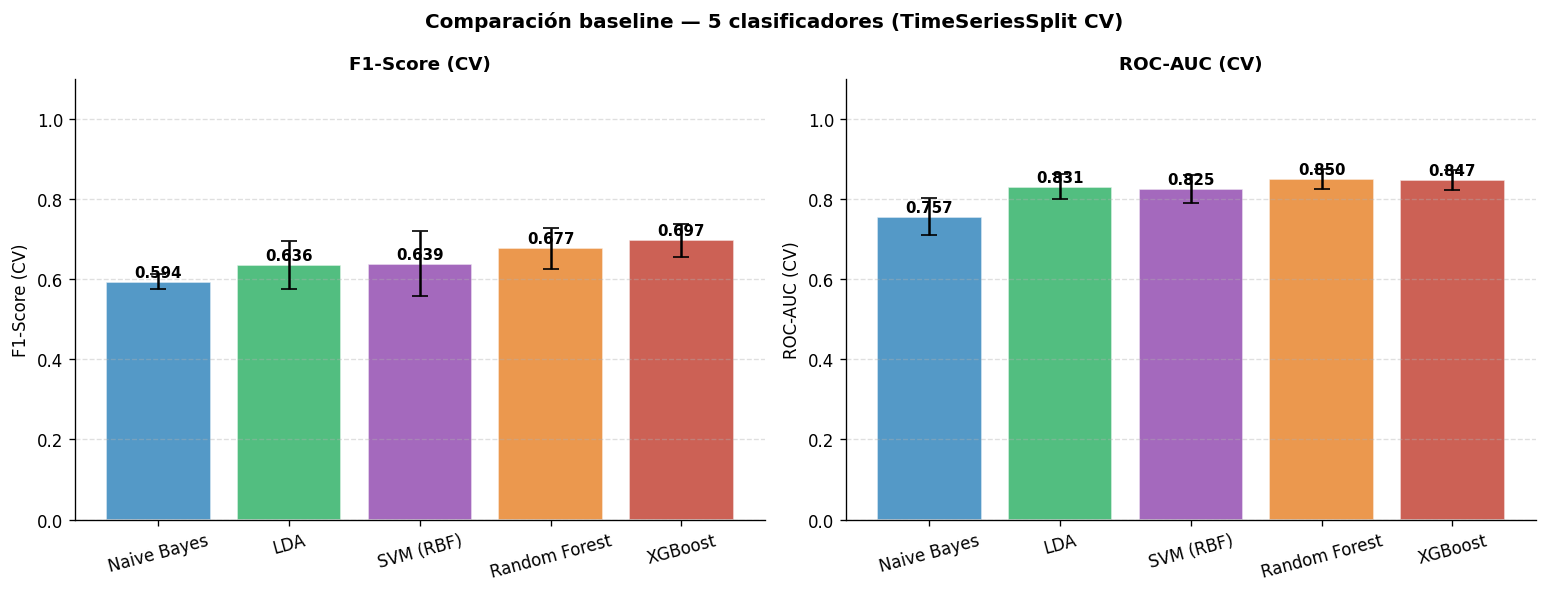

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Comparación baseline — 5 clasificadores (TimeSeriesSplit CV)", fontsize=12, fontweight="bold")

colors = ["#2980B9", "#27AE60", "#8E44AD", "#E67E22", "#C0392B"]
names = list(baseline_results.keys())

for ax, metric, metric_std, title in [
    (axes[0], "cv_f1_mean", "cv_f1_std", "F1-Score (CV)"),
    (axes[1], "cv_roc_auc_mean", "cv_roc_auc_std", "ROC-AUC (CV)"),
]:
    vals = [baseline_results[n][metric] for n in names]
    errs = [baseline_results[n][metric_std] for n in names]
    bars = ax.bar(names, vals, yerr=errs, color=colors, alpha=0.8,
                  capsize=5, edgecolor="white")
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_ylim(0, 1.1)
    ax.set_ylabel(title)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("outputs/cv_baseline_comparison.png", bbox_inches="tight")
plt.show()

## 5. Calibración de hiperparámetros

### 5.1 Naive Bayes — var_smoothing

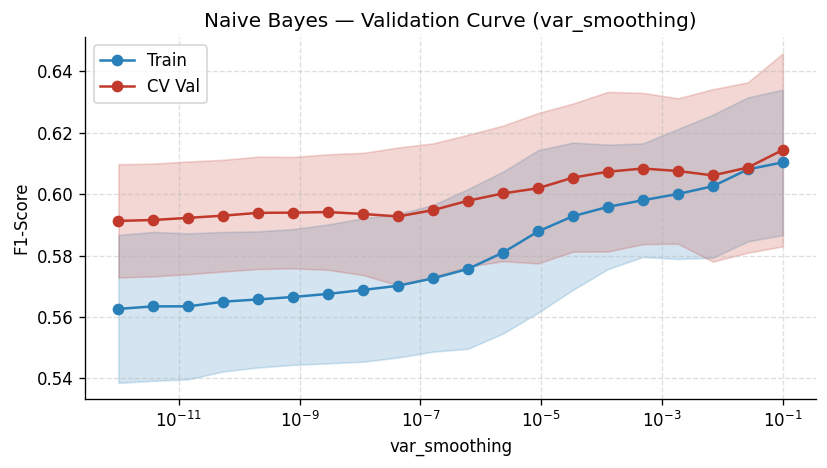

Mejor var_smoothing: 1.00e-01  →  CV F1: 0.6144


In [6]:
os.makedirs("outputs/naive_bayes", exist_ok=True)

param_range_nb = np.logspace(-12, -1, 20)
pipe_nb = Pipeline([("scaler", StandardScaler()), ("clf", GaussianNB())])

train_scores_nb, val_scores_nb = validation_curve(
    pipe_nb, X_train, y_train,
    param_name="clf__var_smoothing", param_range=param_range_nb,
    cv=tscv, scoring="f1", n_jobs=N_JOBS
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(param_range_nb, train_scores_nb.mean(axis=1), "o-", color="#2980B9", label="Train")
ax.fill_between(param_range_nb, train_scores_nb.mean(axis=1) - train_scores_nb.std(axis=1),
                train_scores_nb.mean(axis=1) + train_scores_nb.std(axis=1), alpha=0.2, color="#2980B9")
ax.semilogx(param_range_nb, val_scores_nb.mean(axis=1), "o-", color="#C0392B", label="CV Val")
ax.fill_between(param_range_nb, val_scores_nb.mean(axis=1) - val_scores_nb.std(axis=1),
                val_scores_nb.mean(axis=1) + val_scores_nb.std(axis=1), alpha=0.2, color="#C0392B")
ax.set_xlabel("var_smoothing")
ax.set_ylabel("F1-Score")
ax.set_title("Naive Bayes — Validation Curve (var_smoothing)")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("outputs/naive_bayes/val_curve_var_smoothing.png", bbox_inches="tight")
plt.show()

best_vs_nb = param_range_nb[val_scores_nb.mean(axis=1).argmax()]
print(f"Mejor var_smoothing: {best_vs_nb:.2e}  →  CV F1: {val_scores_nb.mean(axis=1).max():.4f}")


### 5.2 LDA — shrinkage

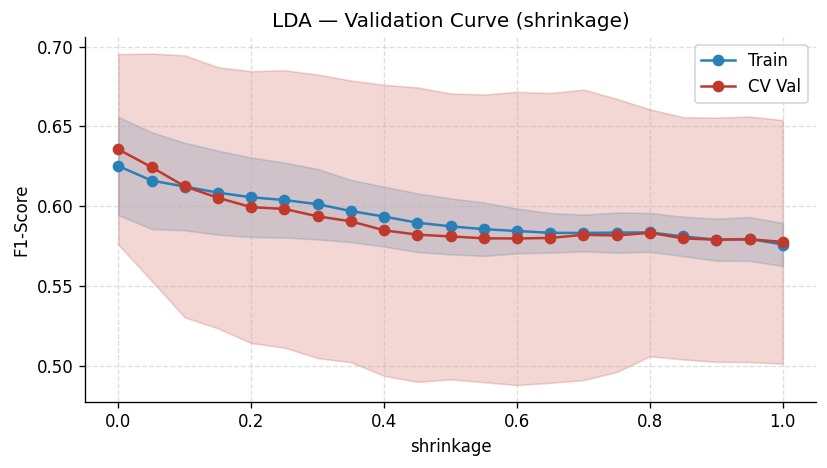

Mejor shrinkage: 0.00  →  CV F1: 0.6356


In [7]:
os.makedirs("outputs/lda", exist_ok=True)

param_range_lda = np.linspace(0.0, 1.0, 21)
pipe_lda = Pipeline([("scaler", StandardScaler()),
                     ("clf", LinearDiscriminantAnalysis(solver="lsqr"))])

train_scores_lda, val_scores_lda = validation_curve(
    pipe_lda, X_train, y_train,
    param_name="clf__shrinkage", param_range=param_range_lda,
    cv=tscv, scoring="f1", n_jobs=N_JOBS
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(param_range_lda, train_scores_lda.mean(axis=1), "o-", color="#2980B9", label="Train")
ax.fill_between(param_range_lda, train_scores_lda.mean(axis=1) - train_scores_lda.std(axis=1),
                train_scores_lda.mean(axis=1) + train_scores_lda.std(axis=1), alpha=0.2, color="#2980B9")
ax.plot(param_range_lda, val_scores_lda.mean(axis=1), "o-", color="#C0392B", label="CV Val")
ax.fill_between(param_range_lda, val_scores_lda.mean(axis=1) - val_scores_lda.std(axis=1),
                val_scores_lda.mean(axis=1) + val_scores_lda.std(axis=1), alpha=0.2, color="#C0392B")
ax.set_xlabel("shrinkage")
ax.set_ylabel("F1-Score")
ax.set_title("LDA — Validation Curve (shrinkage)")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("outputs/lda/val_curve_Shrinkage.png", bbox_inches="tight")
plt.show()

best_shrinkage = param_range_lda[val_scores_lda.mean(axis=1).argmax()]
print(f"Mejor shrinkage: {best_shrinkage:.2f}  →  CV F1: {val_scores_lda.mean(axis=1).max():.4f}")


### 5.3 SVM — C (kernel RBF)

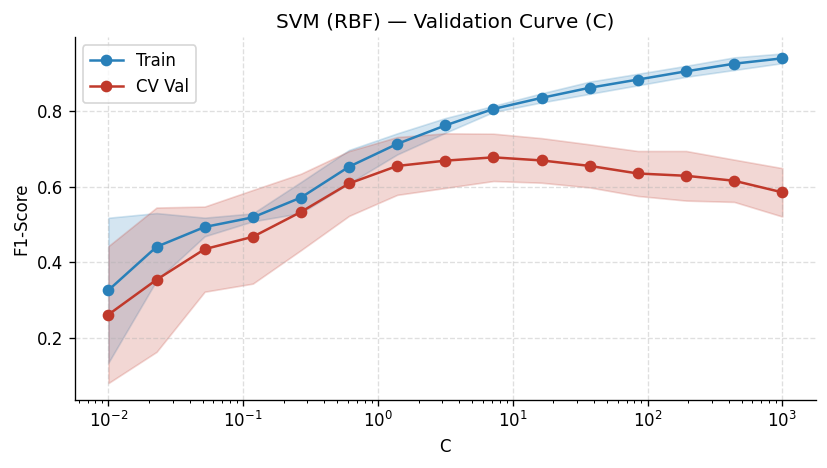

SVM — Mejor config: {'clf__C': 10.0, 'clf__kernel': 'rbf'}
SVM — Mejor CV F1:  0.6756


In [8]:
os.makedirs("outputs/svm", exist_ok=True)

param_range_svm = np.logspace(-2, 3, 15)
pipe_svm = Pipeline([("scaler", StandardScaler()),
                     ("clf", SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE))])

train_scores_svm, val_scores_svm = validation_curve(
    pipe_svm, X_train, y_train,
    param_name="clf__C", param_range=param_range_svm,
    cv=tscv, scoring="f1"
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(param_range_svm, train_scores_svm.mean(axis=1), "o-", color="#2980B9", label="Train")
ax.fill_between(param_range_svm, train_scores_svm.mean(axis=1) - train_scores_svm.std(axis=1),
                train_scores_svm.mean(axis=1) + train_scores_svm.std(axis=1), alpha=0.2, color="#2980B9")
ax.semilogx(param_range_svm, val_scores_svm.mean(axis=1), "o-", color="#C0392B", label="CV Val")
ax.fill_between(param_range_svm, val_scores_svm.mean(axis=1) - val_scores_svm.std(axis=1),
                val_scores_svm.mean(axis=1) + val_scores_svm.std(axis=1), alpha=0.2, color="#C0392B")
ax.set_xlabel("C")
ax.set_ylabel("F1-Score")
ax.set_title("SVM (RBF) — Validation Curve (C)")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("outputs/svm/val_curve_C.png", bbox_inches="tight")
plt.show()

# Grid kernel × C
param_grid_svm = {"clf__kernel": ["linear", "rbf", "poly"],
                  "clf__C": [0.1, 1.0, 10.0, 100.0]}
gs_svm = GridSearchCV(pipe_svm, param_grid_svm, cv=tscv, scoring="f1", n_jobs=N_JOBS)
gs_svm.fit(X_train, y_train)

print(f"SVM — Mejor config: {gs_svm.best_params_}")
print(f"SVM — Mejor CV F1:  {gs_svm.best_score_:.4f}")


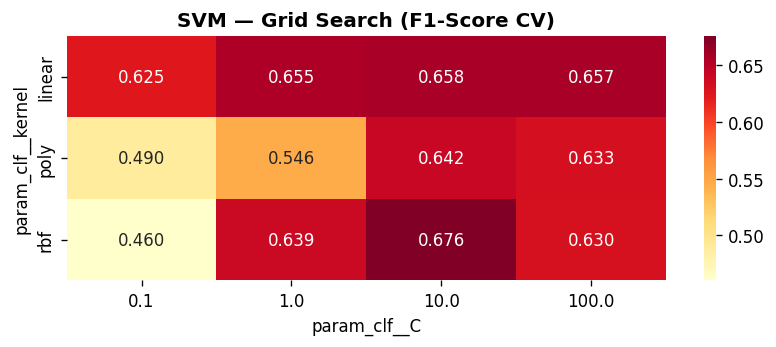

In [9]:
# Heatmap grid search SVM
svm_results = pd.DataFrame(gs_svm.cv_results_)
pivot_svm = svm_results.pivot_table(
    index="param_clf__kernel", columns="param_clf__C", values="mean_test_score"
)

fig, ax = plt.subplots(figsize=(7, 3))
sns_imported = False
try:
    import seaborn as sns
    sns.heatmap(pivot_svm, annot=True, fmt=".3f", cmap="YlOrRd", ax=ax)
    sns_imported = True
except:
    pass
if not sns_imported:
    im = ax.imshow(pivot_svm.values, cmap="YlOrRd", aspect="auto")
    ax.set_xticks(range(len(pivot_svm.columns)))
    ax.set_yticks(range(len(pivot_svm.index)))
    ax.set_xticklabels(pivot_svm.columns)
    ax.set_yticklabels(pivot_svm.index)
ax.set_title("SVM — Grid Search (F1-Score CV)", fontweight="bold")
plt.tight_layout()
plt.savefig("outputs/svm/hyperparam_grid.png", bbox_inches="tight")
plt.show()

### 5.4 XGBoost — learning_rate, max_depth, n_estimators

XGBoost reemplaza KNN. XGBoost ofrece:
- Mejor manejo del desbalance via `scale_pos_weight`
- Regularizacion integrada (lambda, alpha, gamma)
- Importancia de features nativa


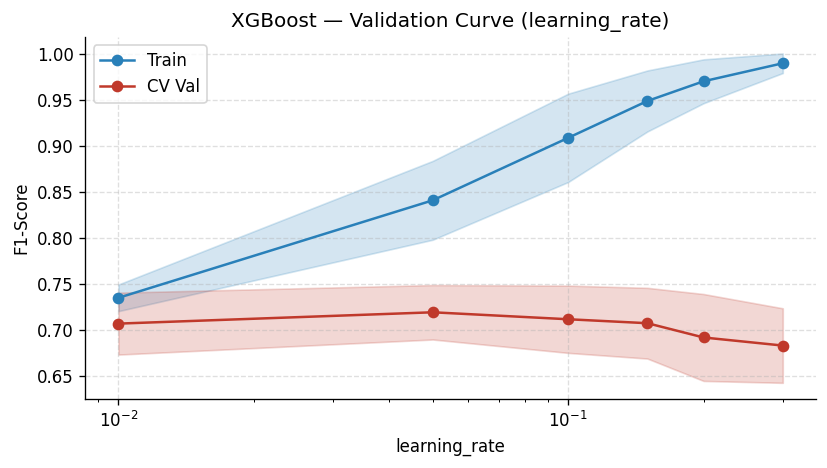

XGBoost — Mejor config: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 200}
XGBoost — Mejor CV F1:  0.7228


In [10]:
os.makedirs("outputs/xgboost", exist_ok=True)

spw = (y_train == 0).sum() / (y_train == 1).sum()

# Validation curve para learning_rate
param_range_xgb_lr = [0.01, 0.05, 0.1, 0.15, 0.2, 0.3]
pipe_xgb = Pipeline([("scaler", StandardScaler()),
                     ("clf", XGBClassifier(
                         n_estimators=200, max_depth=5,
                         scale_pos_weight=spw,
                         random_state=RANDOM_STATE,
                         eval_metric="logloss", verbosity=0))])

train_scores_xgb, val_scores_xgb = validation_curve(
    pipe_xgb, X_train, y_train,
    param_name="clf__learning_rate", param_range=param_range_xgb_lr,
    cv=tscv, scoring="f1", n_jobs=N_JOBS
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(param_range_xgb_lr, train_scores_xgb.mean(axis=1), "o-", color="#2980B9", label="Train")
ax.fill_between(param_range_xgb_lr, train_scores_xgb.mean(axis=1) - train_scores_xgb.std(axis=1),
                train_scores_xgb.mean(axis=1) + train_scores_xgb.std(axis=1), alpha=0.2, color="#2980B9")
ax.semilogx(param_range_xgb_lr, val_scores_xgb.mean(axis=1), "o-", color="#C0392B", label="CV Val")
ax.fill_between(param_range_xgb_lr, val_scores_xgb.mean(axis=1) - val_scores_xgb.std(axis=1),
                val_scores_xgb.mean(axis=1) + val_scores_xgb.std(axis=1), alpha=0.2, color="#C0392B")
ax.set_xlabel("learning_rate")
ax.set_ylabel("F1-Score")
ax.set_title("XGBoost — Validation Curve (learning_rate)")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("outputs/xgboost/val_curve_learning_rate.png", bbox_inches="tight")
plt.show()

param_grid_xgb = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [3, 5, 7],
    "clf__learning_rate": [0.05, 0.1],
}
gs_xgb = GridSearchCV(pipe_xgb, param_grid_xgb, cv=tscv, scoring="f1", n_jobs=N_JOBS)
gs_xgb.fit(X_train, y_train)

print(f"XGBoost — Mejor config: {gs_xgb.best_params_}")
print(f"XGBoost — Mejor CV F1:  {gs_xgb.best_score_:.4f}")


### 5.5 Random Forest — max_depth, n_estimators, min_samples_leaf

El baseline RF muestra overfitting severo (Train F1=1.0, CV F1=0.69).
Se agrega regularizacion: max_depth acotado y min_samples_leaf para controlar la complejidad.


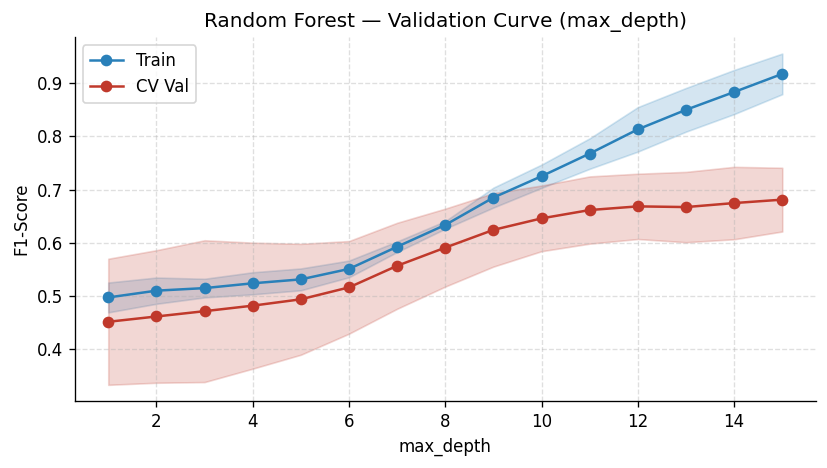

RF — Mejor config: {'clf__max_depth': 10, 'clf__min_samples_leaf': 3, 'clf__n_estimators': 300}
RF — Mejor CV F1:  0.6451


In [11]:
os.makedirs("outputs/rf", exist_ok=True)

param_range_rf_depth = list(range(1, 16))
pipe_rf = Pipeline([("scaler", StandardScaler()),
                    ("clf", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE))])

train_scores_rf, val_scores_rf = validation_curve(
    pipe_rf, X_train, y_train,
    param_name="clf__max_depth", param_range=param_range_rf_depth,
    cv=tscv, scoring="f1", n_jobs=N_JOBS
)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(param_range_rf_depth, train_scores_rf.mean(axis=1), "o-", color="#2980B9", label="Train")
ax.fill_between(param_range_rf_depth,
                train_scores_rf.mean(axis=1) - train_scores_rf.std(axis=1),
                train_scores_rf.mean(axis=1) + train_scores_rf.std(axis=1), alpha=0.2, color="#2980B9")
ax.plot(param_range_rf_depth, val_scores_rf.mean(axis=1), "o-", color="#C0392B", label="CV Val")
ax.fill_between(param_range_rf_depth,
                val_scores_rf.mean(axis=1) - val_scores_rf.std(axis=1),
                val_scores_rf.mean(axis=1) + val_scores_rf.std(axis=1), alpha=0.2, color="#C0392B")
ax.set_xlabel("max_depth")
ax.set_ylabel("F1-Score")
ax.set_title("Random Forest — Validation Curve (max_depth)")
ax.legend()
ax.grid(linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("outputs/rf/val_curve_max_depth.png", bbox_inches="tight")
plt.show()

# GridSearch con regularizacion para controlar overfitting
param_grid_rf = {
    "clf__n_estimators": [100, 200, 300],
    "clf__max_depth": [4, 6, 8, 10],
    "clf__min_samples_leaf": [3, 5, 10],
}
gs_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=tscv, scoring="f1", n_jobs=N_JOBS)
gs_rf.fit(X_train, y_train)

print(f"RF — Mejor config: {gs_rf.best_params_}")
print(f"RF — Mejor CV F1:  {gs_rf.best_score_:.4f}")


## 6. Comparación antes/después del tuning

In [12]:
# Modelos tuned con mejores hiperparametros de cada GridSearch
spw = (y_train == 0).sum() / (y_train == 1).sum()

tuned_classifiers = {
    "Naive Bayes": GaussianNB(var_smoothing=best_vs_nb),
    "LDA":         LinearDiscriminantAnalysis(solver="lsqr", shrinkage=best_shrinkage),
    "SVM (RBF)":   SVC(**{k.replace("clf__", ""): v for k, v in gs_svm.best_params_.items()},
                       probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
                       n_estimators=gs_rf.best_params_["clf__n_estimators"],
                       max_depth=gs_rf.best_params_["clf__max_depth"],
                       min_samples_leaf=gs_rf.best_params_["clf__min_samples_leaf"],
                       random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(
                       n_estimators=gs_xgb.best_params_["clf__n_estimators"],
                       max_depth=gs_xgb.best_params_["clf__max_depth"],
                       learning_rate=gs_xgb.best_params_["clf__learning_rate"],
                       scale_pos_weight=spw,
                       eval_metric="logloss", verbosity=0,
                       random_state=RANDOM_STATE),
}

tuned_results = {}
for name, clf in tuned_classifiers.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    cv_res = cross_validate(pipe, X_train, y_train, cv=tscv, scoring=SCORING,
                            return_train_score=True, n_jobs=N_JOBS)
    tuned_results[name] = {
        "cv_f1_mean":      cv_res["test_f1"].mean(),
        "cv_f1_std":       cv_res["test_f1"].std(),
        "cv_roc_auc_mean": cv_res["test_roc_auc"].mean(),
        "cv_roc_auc_std":  cv_res["test_roc_auc"].std(),
        "train_f1_mean":   cv_res["train_f1"].mean(),
    }
    print(f"[OK] {name}")

tuned_df = pd.DataFrame(tuned_results).T.round(4)
print("\nTuned CV Results:")
print(tuned_df)


[OK] Naive Bayes
[OK] LDA
[OK] SVM (RBF)
[OK] Random Forest
[OK] XGBoost

Tuned CV Results:
               cv_f1_mean  cv_f1_std  cv_roc_auc_mean  cv_roc_auc_std  \
Naive Bayes        0.6144     0.0314           0.7691          0.0352   
LDA                0.6356     0.0597           0.8312          0.0305   
SVM (RBF)          0.6756     0.0627           0.8111          0.0400   
Random Forest      0.6451     0.0654           0.8570          0.0264   
XGBoost            0.7228     0.0222           0.8604          0.0214   

               train_f1_mean  
Naive Bayes           0.6104  
LDA                   0.6251  
SVM (RBF)             0.8208  
Random Forest         0.6854  
XGBoost               0.8059  


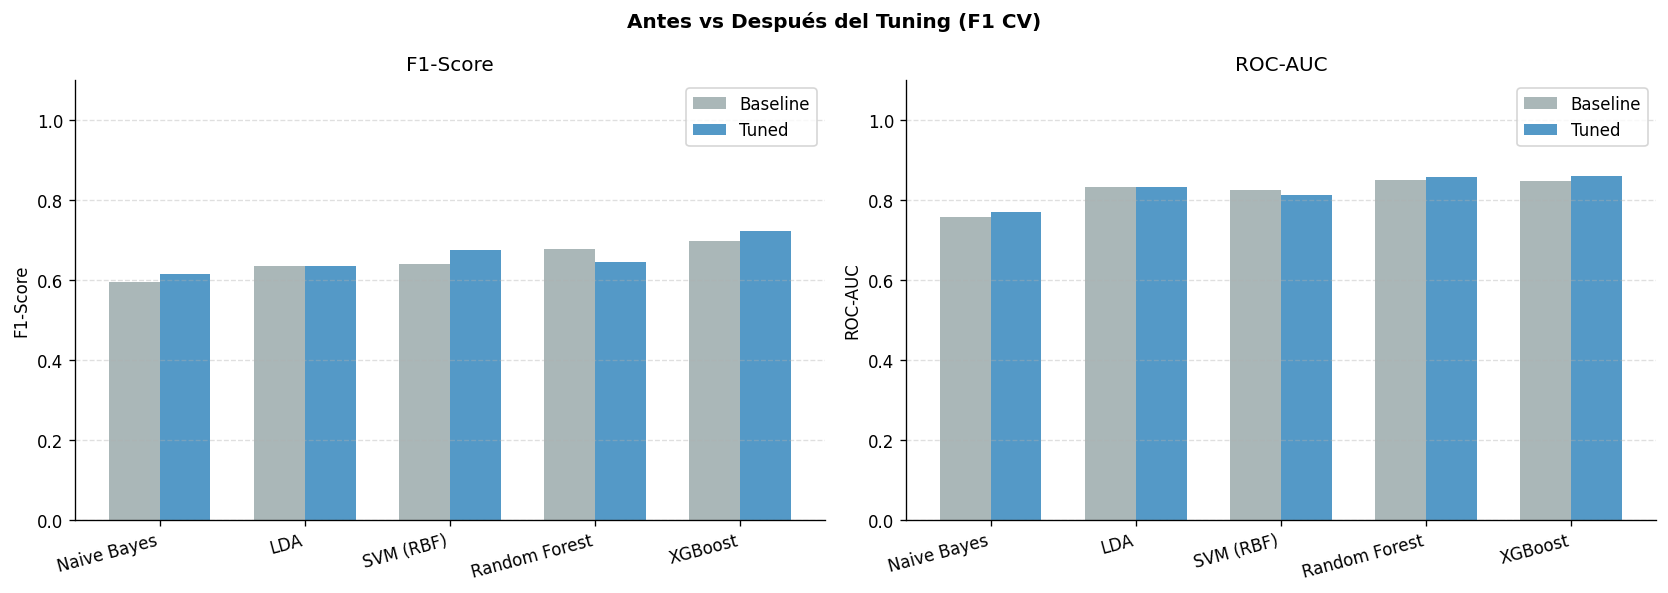

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Antes vs Después del Tuning (F1 CV)", fontsize=12, fontweight="bold")

names = list(baseline_results.keys())
x = np.arange(len(names))
width = 0.35

for ax, metric, title in [
    (axes[0], "cv_f1_mean", "F1-Score"),
    (axes[1], "cv_roc_auc_mean", "ROC-AUC"),
]:
    base_vals = [baseline_results[n][metric] for n in names]
    tuned_vals = [tuned_results[n][metric] for n in names]
    ax.bar(x - width/2, base_vals, width, label="Baseline", color="#95A5A6", alpha=0.8)
    ax.bar(x + width/2, tuned_vals, width, label="Tuned", color="#2980B9", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=15, ha="right")
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.set_ylim(0, 1.1)
    ax.legend()
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("outputs/before_after_tuning.png", bbox_inches="tight")
plt.show()

## 7. Análisis de overfitting (Train vs CV)

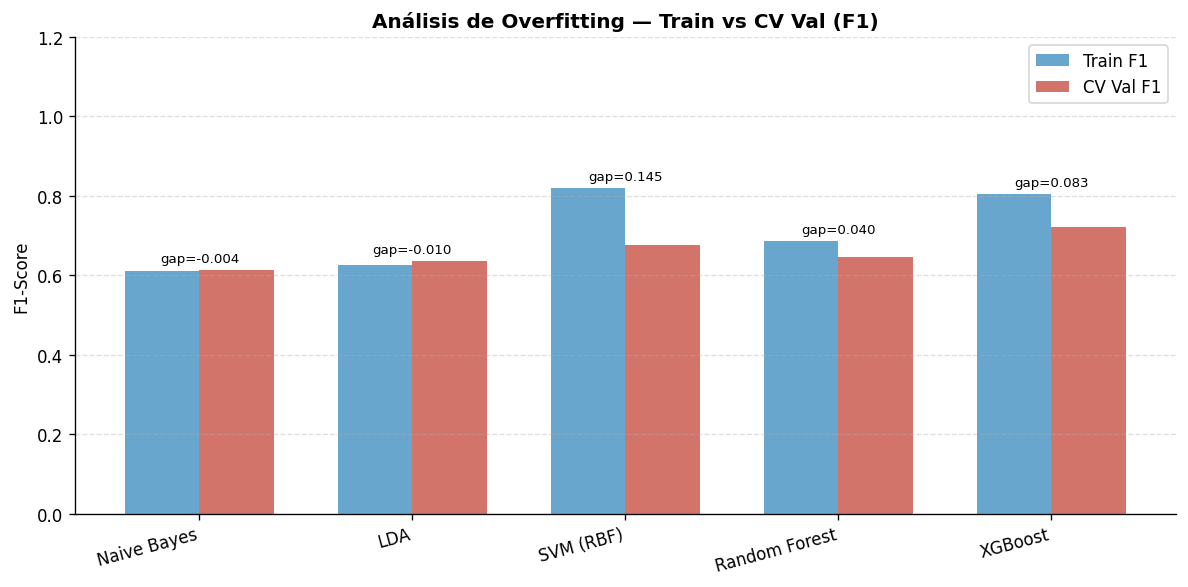

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

names = list(tuned_results.keys())
x = np.arange(len(names))
width = 0.35

train_f1 = [tuned_results[n]["train_f1_mean"] for n in names]
val_f1   = [tuned_results[n]["cv_f1_mean"] for n in names]
gaps     = [t - v for t, v in zip(train_f1, val_f1)]

ax.bar(x - width/2, train_f1, width, label="Train F1", color="#2980B9", alpha=0.7)
ax.bar(x + width/2, val_f1,   width, label="CV Val F1", color="#C0392B", alpha=0.7)

for i, (t, v, g) in enumerate(zip(train_f1, val_f1, gaps)):
    ax.annotate(f"gap={g:.3f}", (x[i], max(t, v) + 0.02), ha="center", fontsize=8, color="black")

ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_ylabel("F1-Score")
ax.set_title("Análisis de Overfitting — Train vs CV Val (F1)", fontweight="bold")
ax.set_ylim(0, 1.2)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("outputs/overfitting_train_vs_cv.png", bbox_inches="tight")
plt.show()

## 8. Selección del modelo baseline y evaluación en test

Seleccionamos el modelo con mejor F1 en CV. Evaluamos **una sola vez** en el test set.

In [15]:
best_model_name = max(tuned_results, key=lambda n: tuned_results[n]["cv_f1_mean"])
best_clf = tuned_classifiers[best_model_name]
best_pipe = Pipeline([("scaler", StandardScaler()), ("clf", best_clf)])
best_pipe.fit(X_train, y_train)

y_pred = best_pipe.predict(X_test)
y_prob = best_pipe.predict_proba(X_test)[:, 1]

test_f1      = f1_score(y_test, y_pred)
test_roc_auc = roc_auc_score(y_test, y_prob)
test_acc     = accuracy_score(y_test, y_pred)

print(f"Mejor modelo: {best_model_name}")
print(f"  CV  F1:      {tuned_results[best_model_name]['cv_f1_mean']:.4f} ± {tuned_results[best_model_name]['cv_f1_std']:.4f}")
print(f"  Test F1:     {test_f1:.4f}")
print(f"  Test ROC-AUC:{test_roc_auc:.4f}")
print(f"  Test Acc:    {test_acc:.4f}")

Mejor modelo: XGBoost
  CV  F1:      0.7228 ± 0.0222
  Test F1:     0.7185
  Test ROC-AUC:0.8772
  Test Acc:    0.8085


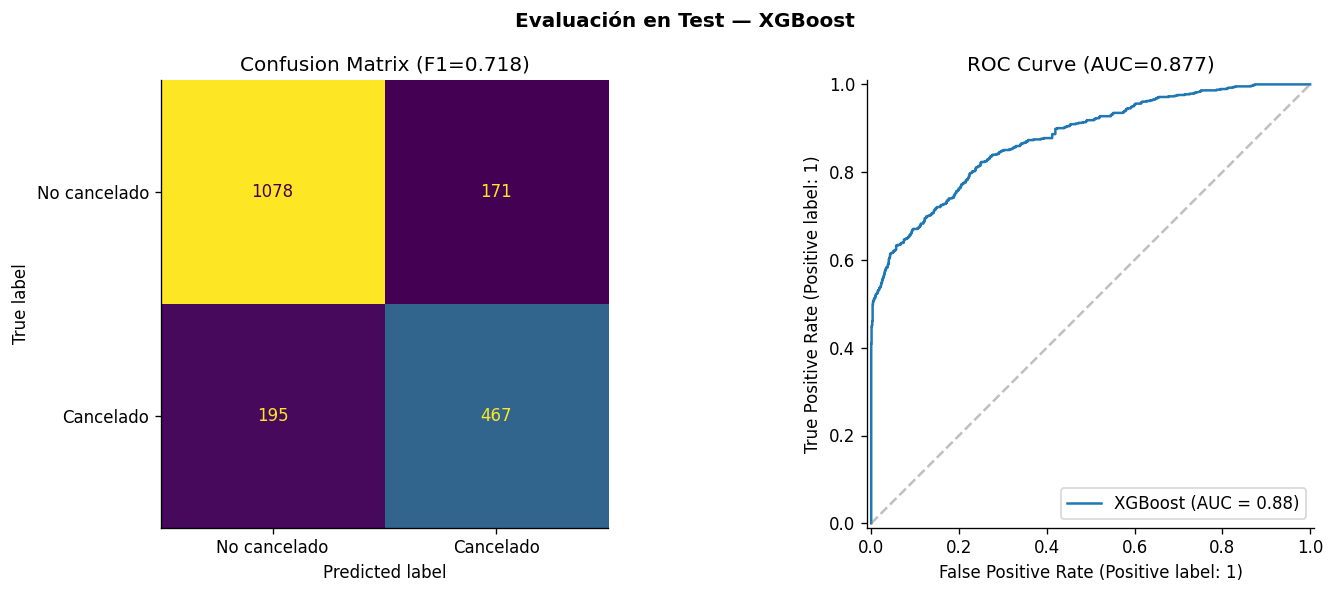


Resumen TEST — todos los modelos:
                   F1  ROC-AUC  Accuracy
Naive Bayes    0.6169   0.8083    0.6536
LDA            0.6311   0.8296    0.8048
SVM (RBF)      0.7058   0.8554    0.8216
Random Forest  0.6539   0.8691    0.8200
XGBoost        0.7185   0.8772    0.8085


In [16]:
# Subdir para el mejor modelo
model_dir = "outputs/" + best_model_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
os.makedirs(model_dir, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Evaluación en Test — {best_model_name}", fontsize=12, fontweight="bold")

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, ax=axes[0], colorbar=False,
    display_labels=["No cancelado", "Cancelado"]
)
axes[0].set_title(f"Confusion Matrix (F1={test_f1:.3f})")

# ROC Curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=best_model_name)
axes[1].set_title(f"ROC Curve (AUC={test_roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "--", color="gray", alpha=0.5)

plt.tight_layout()
plt.savefig(f"{model_dir}/confusion_matrix_test.png", bbox_inches="tight")
plt.savefig(f"{model_dir}/roc_curve_test.png", bbox_inches="tight")
plt.show()

# Métricas de todos los modelos en test
all_test_results = {}
for name, clf in tuned_classifiers.items():
    p = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    p.fit(X_train, y_train)
    yp = p.predict(X_test)
    yprob = p.predict_proba(X_test)[:, 1]
    all_test_results[name] = {
        "F1": f1_score(y_test, yp),
        "ROC-AUC": roc_auc_score(y_test, yprob),
        "Accuracy": accuracy_score(y_test, yp)
    }

test_summary = pd.DataFrame(all_test_results).T.round(4)
print("\nResumen TEST — todos los modelos:")
print(test_summary)

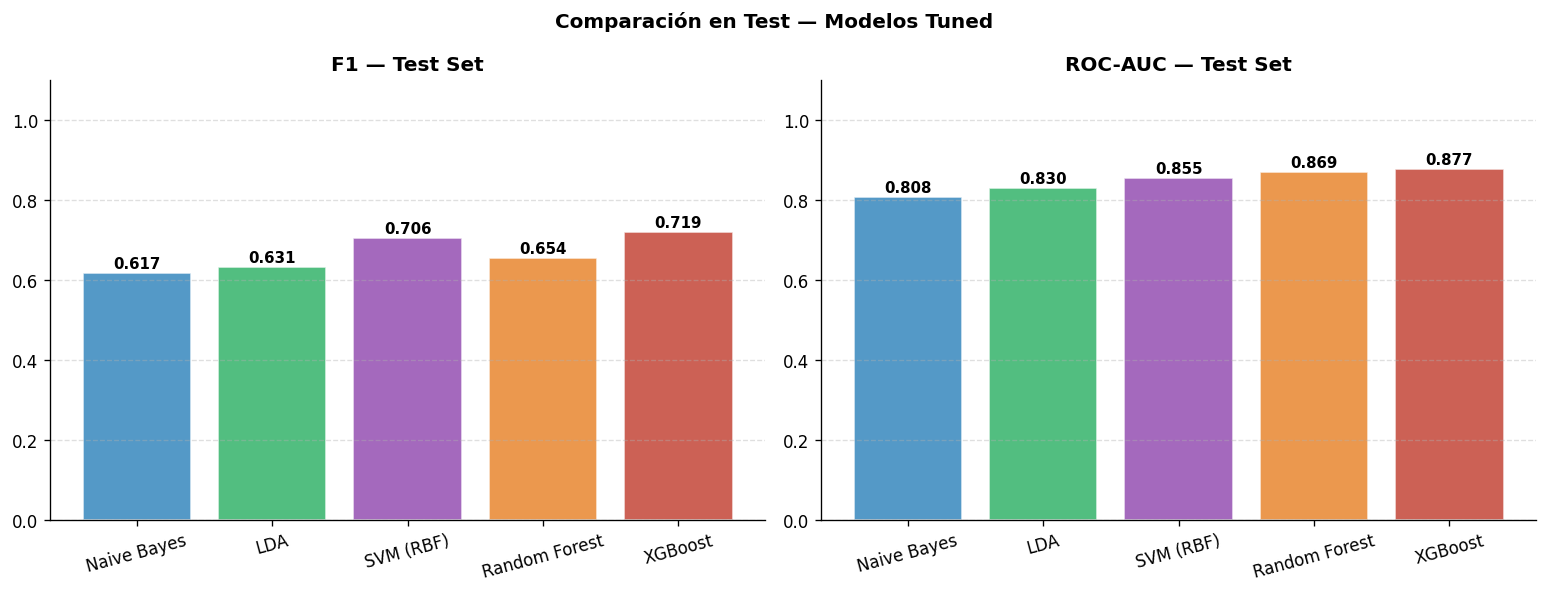


Info del mejor modelo guardada en data/processed/best_model_info.json
{
  "model_name": "XGBoost",
  "cv_f1": 0.7228258274945851,
  "test_f1": 0.7184615384615385,
  "test_roc_auc": 0.8772099250397296
}


In [17]:
# Comparación visual test
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Comparación en Test — Modelos Tuned", fontsize=12, fontweight="bold")

for ax, metric in [(axes[0], "F1"), (axes[1], "ROC-AUC")]:
    vals = test_summary[metric]
    bars = ax.bar(vals.index, vals.values, color=colors, alpha=0.8, edgecolor="white")
    for bar, val in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.set_title(f"{metric} — Test Set", fontweight="bold")
    ax.set_ylim(0, 1.1)
    ax.tick_params(axis="x", rotation=15)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("outputs/test_comparison.png", bbox_inches="tight")
plt.show()

# Guardar info del mejor modelo para notebook 03
import json
best_info = {
    "model_name": best_model_name,
    "cv_f1": tuned_results[best_model_name]["cv_f1_mean"],
    "test_f1": float(test_f1),
    "test_roc_auc": float(test_roc_auc),
}
with open("data/processed/best_model_info.json", "w") as f:
    json.dump(best_info, f, indent=2)
print(f"\nInfo del mejor modelo guardada en data/processed/best_model_info.json")
print(json.dumps(best_info, indent=2))

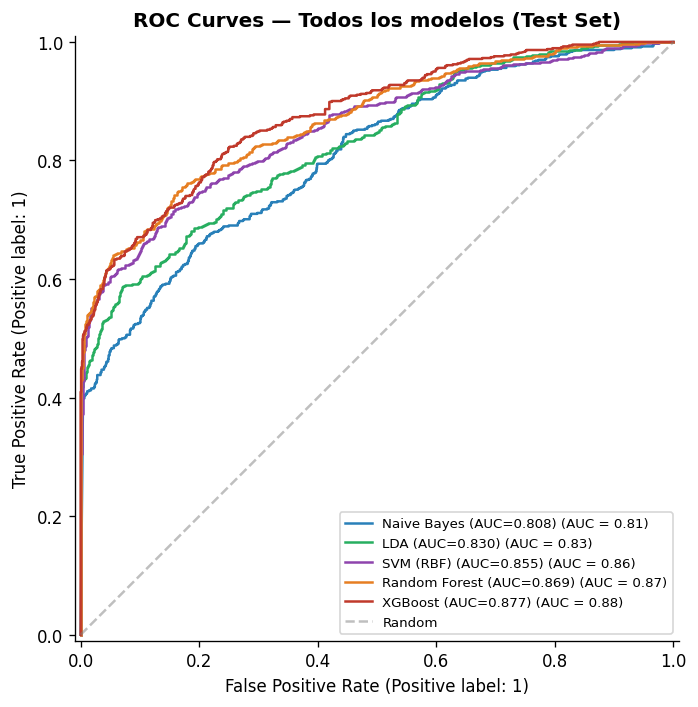

In [18]:
# ROC curves de todos los modelos superpuestos
fig, ax = plt.subplots(figsize=(7, 6))
for (name, clf), color in zip(tuned_classifiers.items(), colors):
    p = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    p.fit(X_train, y_train)
    yprob = p.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, yprob)
    RocCurveDisplay.from_predictions(y_test, yprob, ax=ax, name=f"{name} (AUC={auc:.3f})", color=color)

ax.plot([0, 1], [0, 1], "--", color="gray", alpha=0.5, label="Random")
ax.set_title("ROC Curves — Todos los modelos (Test Set)", fontweight="bold")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig("outputs/roc_all_models.png", bbox_inches="tight")
plt.show()

In [19]:
# Guardar el modelo entrenado para uso en notebook 03
import pickle

with open("data/processed/best_pipeline.pkl", "wb") as f:
    pickle.dump(best_pipe, f)

print(f"Pipeline guardado en data/processed/best_pipeline.pkl")
print(f"\n=== BASELINE SELECCIONADO ===")
print(f"Modelo: {best_model_name}")
print(f"CV F1:       {tuned_results[best_model_name]['cv_f1_mean']:.4f}")
print(f"Test F1:     {test_f1:.4f}")
print(f"Test ROC-AUC:{test_roc_auc:.4f}")
print(f"Test Acc:    {test_acc:.4f}")

Pipeline guardado en data/processed/best_pipeline.pkl

=== BASELINE SELECCIONADO ===
Modelo: XGBoost
CV F1:       0.7228
Test F1:     0.7185
Test ROC-AUC:0.8772
Test Acc:    0.8085
